# 10 · Retarget a real TS — mutate catalyst / substrate by SMILES

Notebooks `05`/`06` transferred a geometry across scaffolds; `09` assembled a TS from numbers. This is the
capstone: take a **real DFT transition state** and rebuild it around a *fresh* catalyst or substrate written
as **SMILES**, holding the reacting core exactly where the DFT put it, then conformer-search the new
periphery. Change one SMILES → a new TS candidate.

**What goes in (and what doesn't):**

- the **TS `.xyz`** — only a *source of positions* for the reacting-core atoms;
- the **reacting-core atom indices** — from a `graphrc` bond-change analysis (0-based, xyz order);
- the **fragment SMILES** you want to assemble (`catalyst.substrate`).

You do **not** pass a SMILES *of the TS* — a TS has partial/hypervalent bonds and its perceived SMILES is
unreliable. The core comes from the geometry; the molecule comes from your fragment SMILES; SMARTS ties them
together.

Two ways to tie them, both shown below: for a **rebuild** (same molecule) a whole-fragment substructure match;
for a **mutation** (the fragment changes) small **anchor SMARTS** on the *conserved reacting motif*, which
survive changing the periphery. The `graft` helper is notebook-local — we prove an easy, robust route here
first, then lift it into the library.

In [1]:
import tempfile

import numpy as np
import rxembed as rx
import xyzrender
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolAlign
from rdkit.Chem import rdMolTransforms as T

from rxembed.embed.dispatch import _xyz_to_mol

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")

ORIG, NEW = "#5b8fd6", "#e0736b"  # original TS (blue) vs retargeted molecule (red)


def graft(asm, core_coords, *, chirality="retain", n=6):
    """Embed assembly ``asm`` with ``core_coords`` ({assembly_atom: (x,y,z)}) grafted rigid to the TS.

    ``chirality='retain'`` holds the TS's handedness (the coordinate graft is reflection-correct — right for a
    diastereomeric TS). ``chirality='both'`` ALSO embeds the mirror core (negated z): the two diastereomeric
    TSs, for when a real energy should choose. A distance/angle spec could NOT do this — it is
    reflection-invariant and might silently give the mirror.
    """
    keep = rx.embed(asm, fix=core_coords, n=n)
    if chirality == "retain":
        return keep
    mirror = {i: (x, y, -z) for i, (x, y, z) in core_coords.items()}
    return keep, rx.embed(asm, fix=mirror, n=n)

## 1 · CPA — rebuild the TS from its two fragments

The chiral-phosphoric-acid TS (`cpa.xyz`, 103 atoms): a proton in flight between the phosphate and the
substrate carbonyl with a forming C–C ring closure (`graphrc` reacting bonds `[(23,35),(35,75),(70,74)]`). A
*rebuild* keeps both molecules, so a whole-fragment substructure match ties assembly → TS. The core lands at
**0.000 Å** and the overlay (blue original / red rebuilt) shows the cores coincident.

In [2]:
import itertools

ref = _xyz_to_mol("structures/cpa.xyz", 0)
P = ref.GetConformer().GetPositions()
catalyst = "O=P1(O)Oc2c(-c3cccc4ccccc34)cc3ccccc3c2-c2c(c(-c3cccc4ccccc34)cc3ccccc23)O1"
substrate = "CC(=Cc1ccccc1)C(=O)C1=CCCCO1"
heavy_core, transfer_H = [23, 70, 74, 75], 35  # O(P), C, C, O(subs) + the proton in flight (TS atom 35)

cat_ref = ref.GetSubstructMatch(Chem.MolFromSmiles(catalyst))  # conserved fragments match the TS graph as-is
sub_ref = ref.GetSubstructMatch(Chem.MolFromSmiles(substrate))
ncat = Chem.MolFromSmiles(catalyst).GetNumAtoms()
ts_to_asm = {t: f for f, t in enumerate(cat_ref)} | {t: ncat + f for f, t in enumerate(sub_ref)}

asm = Chem.AddHs(Chem.MolFromSmiles(f"{catalyst}.{substrate}"))
core = {ts_to_asm[t]: tuple(P[t]) for t in heavy_core}  # each heavy core atom -> its DFT position
o23 = ts_to_asm[23]  # the transferring proton is the H on the phosphate -OH (TS atom 35)
core[next(nb.GetIdx() for nb in asm.GetAtomWithIdx(o23).GetNeighbors() if nb.GetAtomicNum() == 1)] = tuple(
    P[transfer_H]
)

ens = graft(asm, core, n=6)
drift = max(
    abs(np.linalg.norm(pos[ts_to_asm[i]] - pos[ts_to_asm[j]]) - np.linalg.norm(P[i] - P[j]))
    for c in ens.ids
    for pos in [ens.mol.GetConformer(c).GetPositions()]
    for i, j in itertools.combinations(heavy_core, 2)
)
print(f"CPA rebuilt from SMILES: {ens.n} conformers | reacting core held to {drift:.4f} A (same as the native embed)")
low = ens.lowest(1)  # align on the reactive core geometrically, then overlay (auto_align off)
rdMolAlign.AlignMol(low.mol, ref, prbCid=low.ids[0], refCid=0, atomMap=[(ts_to_asm[t], t) for t in heavy_core])
xyzrender.render(  # original DFT TS (blue) vs the SMILES-rebuilt one (red)
    xyzrender.load("structures/cpa.xyz"),
    mol_color=ORIG,
    overlay=low.dump(tempfile.mktemp(suffix=".xyz")),
    overlay_color=NEW,
    auto_align=False,
    no_hy=True,
)

rxembed | stereo='racemic': 1 undefined stereocentre(s) detected -> deliberately embedding 2 stereoisomer(s) as the racemate/diastereomer set [46=47:Z, 46=47:E]
rxembed | resolve: graft O2, C47, O55, C57, H62
rxembed | embed: bounds smoothing loosened to 0.26 A — these distance/angle constraints are over-tight for this arrangement (near-infeasible); check the embedded geometry
rxembed | embed: 6 seeds (103 atoms, 2 fragments, 10 constraints)
rxembed | stereo='racemic': stereoisomer [46=47:Z] -> 1 candidate(s)
rxembed | resolve: graft O2, C47, O55, C57, H62
rxembed | embed: bounds smoothing loosened to 0.26 A — these distance/angle constraints are over-tight for this arrangement (near-infeasible); check the embedded geometry
rxembed | embed: 6 seeds (103 atoms, 2 fragments, 10 constraints)
rxembed | stereo='racemic': stereoisomer [46=47:E] -> 1 candidate(s)
rxembed | stereo='racemic': 2 stereoisomers folded into one EnsembleSet — select/score each; do NOT energy-prune ACROSS them (disti

AttributeError: 'EnsembleSet' object has no attribute 'ids'

## 2 · jacob_ts4 — a diastereomeric FLP TS, mutate catalyst / substrate / both

A 70-atom frustrated-Lewis-pair TS: a hydride in flight between two borons (`graphrc` core `[3,32,11,27]` =
C, B, B, H). The catalyst is an *ortho*-(tetramethylpiperidinyl)arylborane whose hindered rotations make the
TS **diastereomeric**.

Now the real point — **mutate a fragment.** Once a fragment changes it no longer matches the TS whole, so we
locate the reacting atoms by **anchor SMARTS on the conserved motif** (the aryl-borane, the pinacol boronate)
— these survive swapping the periphery. Three mutations, one recipe: swap the substrate (thienyl→phenyl),
swap the catalyst (TMP→piperidine), and swap **both**. In every case the B–B and B–H reacting distances hold
exactly, and the overlay shows the new molecule (red) on the original TS (blue).

rxembed | resolve: graft B0, C1, B21, H32


rxembed | embed: 6 seeds (73 atoms, 2 fragments, 6 constraints)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 2.9, 3.5, 4.0, 4.1, 8.3] | window=250 -> all within window
rxembed | prune[rmsd]: 6 -> 6  (merged 0 near-duplicates; see .duplicates())


  swap substrate  (thienyl->phenyl) : 6 confs | B-B 2.164 (DFT 2.164) | B-H 1.226 (DFT 1.226)


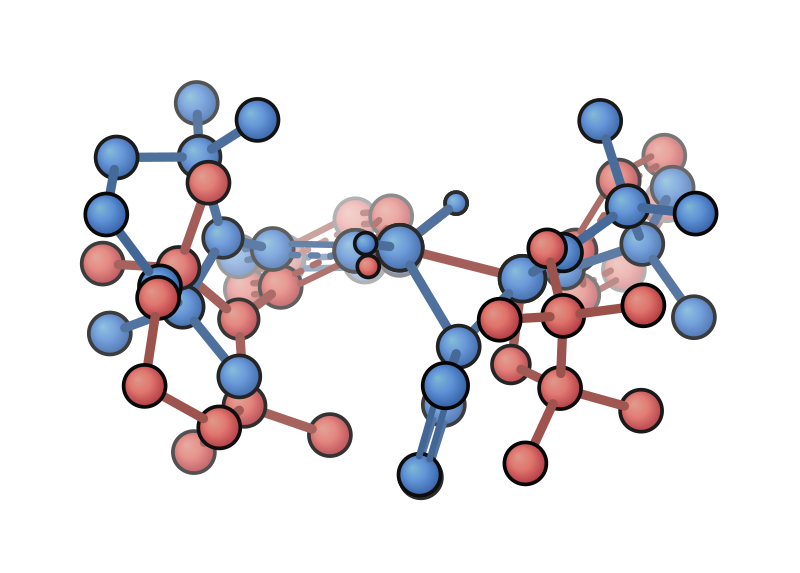

rxembed | resolve: graft B0, C1, B17, H27
rxembed | embed: 6 seeds (58 atoms, 2 fragments, 6 constraints)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 4.4, 4.9, 5.3, 7.6, 7.8] | window=250 -> all within window
rxembed | prune[rmsd]: 6 -> 6  (merged 0 near-duplicates; see .duplicates())


  swap catalyst   (TMP->piperidine) : 6 confs | B-B 2.164 (DFT 2.164) | B-H 1.226 (DFT 1.226)


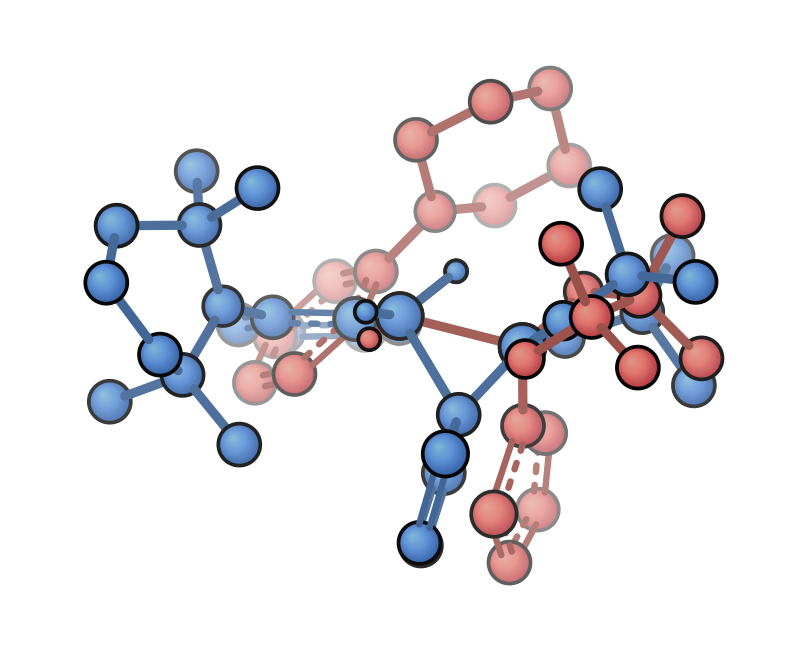

rxembed | resolve: graft B0, C1, B17, H28
rxembed | embed: 6 seeds (61 atoms, 2 fragments, 6 constraints)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 3.6, 4.1, 5.5, 5.8, 17.4] | window=250 -> all within window
rxembed | prune[rmsd]: 6 -> 6  (merged 0 near-duplicates; see .duplicates())


  swap BOTH                         : 6 confs | B-B 2.164 (DFT 2.164) | B-H 1.226 (DFT 1.226)


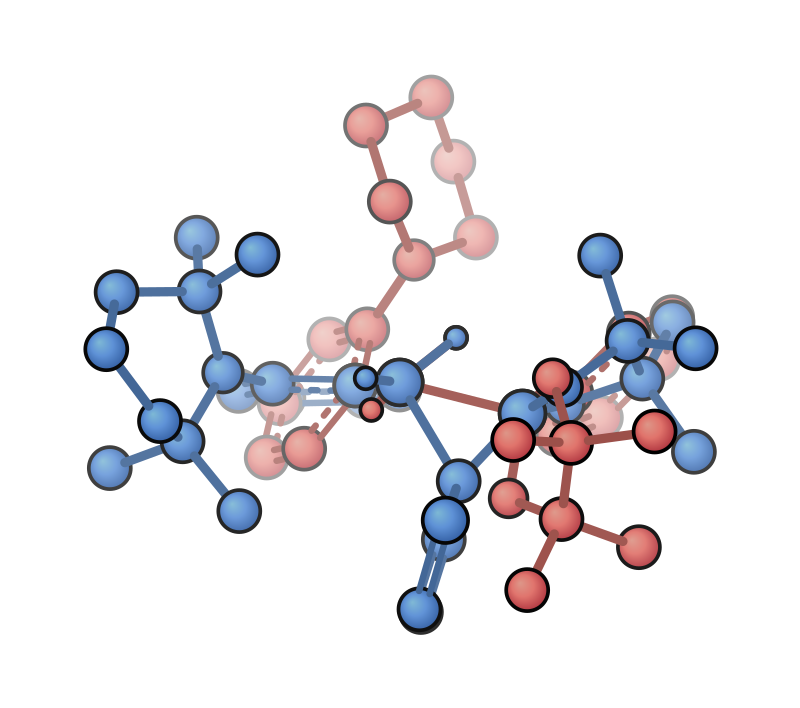

In [3]:
ref = _xyz_to_mol("structures/jacob_ts4.xyz", 0)
P = ref.GetConformer().GetPositions()

# anchor SMARTS on the conserved reacting motifs (survive mutating the periphery):
BORANE_B = "[#5;$([#5]c);!$([#5]O)]"  # aryl-borane boron (NOT bonded to O)
BORONATE_B = "[#5;$([#5]O)]"  # pinacol boronate boron (bonded to O)
IPSO_C = "[#5;!$([#5]O)]c"  # borane boron + its ipso aromatic C (a 4th atom to orient the graft)
# TS core positions to graft onto: borane B=11, boronate B=32, hydride=27, ipso C=1 (graphrc + the frame atom)

MUTATIONS = {
    "swap substrate  (thienyl->phenyl)": ("Bc1ccccc1N1C(C)(C)CCCC1(C)C", "CC1(C)OB(c2ccccc2)OC1(C)C"),
    "swap catalyst   (TMP->piperidine)": ("Bc1ccccc1N1CCCCC1", "CC1(C)OB(c2cccs2)OC1(C)C"),
    "swap BOTH": ("Bc1ccccc1N1CCCCC1", "CC1(C)OB(c2ccccc2)OC1(C)C"),
}
for label, (cat, sub) in MUTATIONS.items():
    asm = Chem.AddHs(Chem.MolFromSmiles(f"{cat}.{sub}"))
    bB = asm.GetSubstructMatch(Chem.MolFromSmarts(BORANE_B))[0]  # reacting atoms, found by anchor on the new molecule
    oB = asm.GetSubstructMatch(Chem.MolFromSmarts(BORONATE_B))[0]
    ipso = asm.GetSubstructMatch(Chem.MolFromSmarts(IPSO_C))[1]
    hyd = next(nb.GetIdx() for nb in asm.GetAtomWithIdx(bB).GetNeighbors() if nb.GetAtomicNum() == 1)
    core = {bB: tuple(P[11]), oB: tuple(P[32]), hyd: tuple(P[27]), ipso: tuple(P[1])}
    ens = graft(asm, core, n=6).minimize().prune()
    bb = np.mean([T.GetBondLength(ens.mol.GetConformer(c), bB, oB) for c in ens.ids])
    bh = np.mean([T.GetBondLength(ens.mol.GetConformer(c), bB, hyd) for c in ens.ids])
    print(f"  {label:34s}: {ens.n} confs | B-B {bb:.3f} (DFT 2.164) | B-H {bh:.3f} (DFT 1.226)")
    low = ens.lowest(1)  # geometric align on the reactive core (the grafted atoms), then overlay
    rdMolAlign.AlignMol(low.mol, ref, prbCid=low.ids[0], refCid=0, atomMap=[(bB, 11), (oB, 32), (hyd, 27), (ipso, 1)])
    display(
        xyzrender.render(  # original (blue) vs mutant (red), superposed on the reacting core
            xyzrender.load("structures/jacob_ts4.xyz"),
            mol_color=ORIG,
            overlay=low.dump(tempfile.mktemp(suffix=".xyz")),
            overlay_color=NEW,
            auto_align=False,
            no_hy=True,
        )
    )

## 3 · The diastereomer switch — retain vs. embed both

Because the graft carries the exact 3-D core, handedness is explicit. `chirality='retain'` reproduces the DFT
TS's hand; `chirality='both'` also embeds the mirror core — the other diastereomer — so a real energy can
decide which the new fragments prefer. The sign of the core's signed volume proves the two are opposite
hands.

In [ ]:
cat, sub = "Bc1ccccc1N1CCCCC1", "CC1(C)OB(c2ccccc2)OC1(C)C"  # the both-swapped assembly
asm = Chem.AddHs(Chem.MolFromSmiles(f"{cat}.{sub}"))
bB = asm.GetSubstructMatch(Chem.MolFromSmarts(BORANE_B))[0]
oB = asm.GetSubstructMatch(Chem.MolFromSmarts(BORONATE_B))[0]
ipso = asm.GetSubstructMatch(Chem.MolFromSmarts(IPSO_C))[1]
hyd = next(nb.GetIdx() for nb in asm.GetAtomWithIdx(bB).GetNeighbors() if nb.GetAtomicNum() == 1)
core = {bB: tuple(P[11]), oB: tuple(P[32]), hyd: tuple(P[27]), ipso: tuple(P[1])}


def hand(mol, cid):
    p = mol.GetConformer(cid).GetPositions()
    a, b, c, d = (p[i] for i in (ipso, oB, bB, hyd))
    return int(np.sign(np.dot(np.cross(b - a, c - a), d - a)))


keep, mirror = graft(asm, core, chirality="both", n=6)
print(f"retain: {keep.n} confs, core hand {sorted({hand(keep.mol, c) for c in keep.ids})}")
print(
    f"both  : + {mirror.n} mirror confs, core hand {sorted({hand(mirror.mol, c) for c in mirror.ids})}  "
    f"(opposite => the other diastereomer)"
)

rxembed | resolve: graft B0, C1, B17, H28
rxembed | embed: 6 seeds (61 atoms, 2 fragments, 6 constraints)
rxembed | resolve: graft B0, C1, B17, H28
rxembed | embed: 6 seeds (61 atoms, 2 fragments, 6 constraints)


retain: 6 confs, core hand [-1]
both  : + 6 mirror confs, core hand [1]  (opposite => the other diastereomer)


## 4 · thia-ma — a charged sulfa-Michael TS, swap the acyl isothiouronium

An isothiourea-catalysed sulfa-Michael addition (`thia-ma.xyz`, 83 atoms): a **cationic acyl isothiouronium**
(HyperBTM bearing a CF₃-enoyl Michael acceptor) and a **deprotonated** bis(*p*-nitrophenyl)thiourea nucleophile
— opposite charges, net neutral. `graphrc` gives the forming bond `(35,47)` = the thiourea S adding to the
acceptor β-carbon.

The mutation: **replace the acyl isothiouronium, hold the acyl.** Because the CF₃-enoyl acyl (and its reacting
β-carbon) is conserved, we graft the *whole acyl* plus the thiourea core onto their DFT positions and hang a
fresh isothiourea backbone off it — the forming C–S bond held at 2.266 Å each time, both formal charges
preserved. Four backbones: HyperBTM → BTM → *p*-tolyl, and a nitro-fused benzothiazolium **acylated at its
Lewis-base imine N** (→ N⁺, the cationic acyl isothiouronium). A new backbone SMILES carrying the same
`C(=O)/C=C/C(F)(F)F` acyl on that N is all it takes.

rxembed | resolve: graft C15, O16, C17, C18, C19, F20, F21, F22, N37, C38, S39, N40
rxembed | embed: 12 seeds (83 atoms, 2 fragments, 66 constraints)
rxembed | minimize: dropped 6 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 6 kept
rxembed | prune[rmsd]: 6 -> 6  (merged 0 near-duplicates; see .duplicates())


  HyperBTM (original)   : 6 confs | forming C(beta)-S held 2.266 A (DFT 2.266) | net charge 0


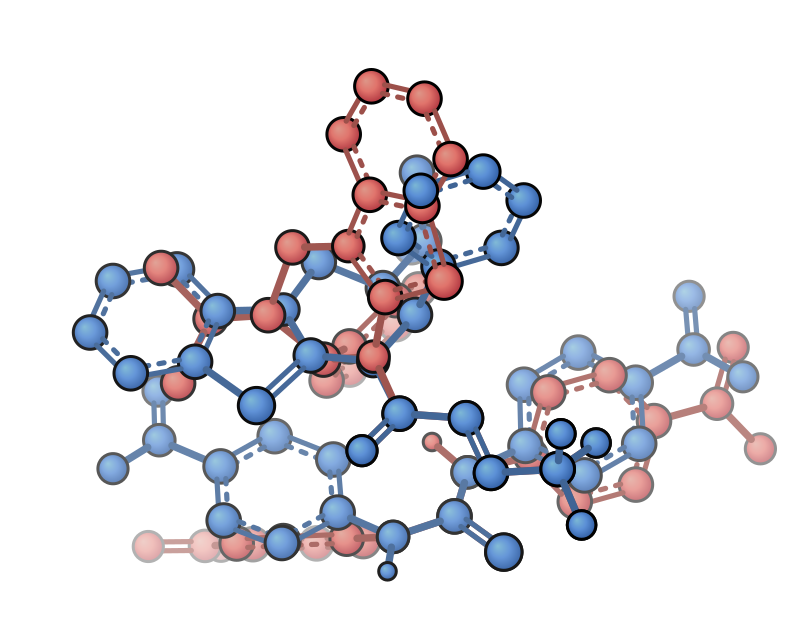

rxembed | resolve: graft C12, O13, C14, C15, C16, F17, F18, F19, N34, C35, S36, N37
rxembed | embed: 12 seeds (74 atoms, 2 fragments, 66 constraints)
rxembed | minimize: dropped 7 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 5 kept
rxembed | prune[rmsd]: 5 -> 5  (merged 0 near-duplicates; see .duplicates())


  BTM (drop the i-Pr)   : 5 confs | forming C(beta)-S held 2.266 A (DFT 2.266) | net charge 0


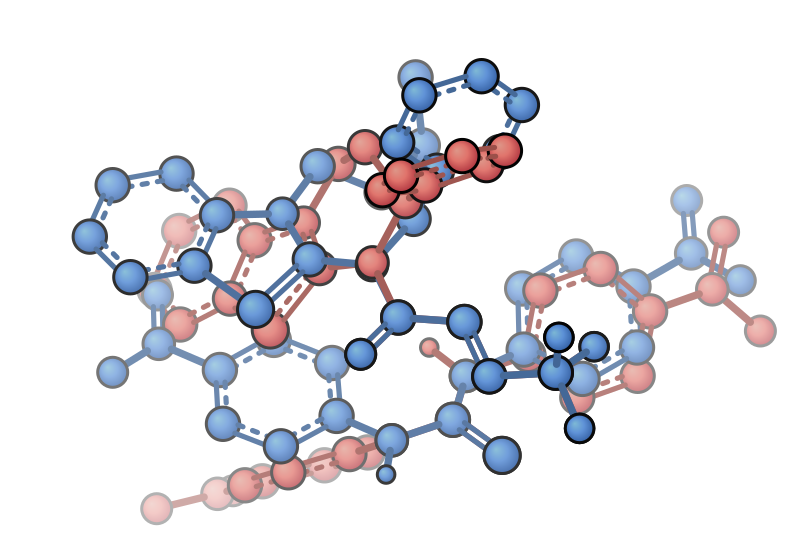

rxembed | resolve: graft C15, O16, C17, C18, C19, F20, F21, F22, N38, C39, S40, N41
rxembed | embed: 12 seeds (86 atoms, 2 fragments, 66 constraints)
rxembed | minimize: dropped 5 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 7 kept
rxembed | prune[rmsd]: 7 -> 7  (merged 0 near-duplicates; see .duplicates())


  p-tolyl variant       : 7 confs | forming C(beta)-S held 2.266 A (DFT 2.266) | net charge 0


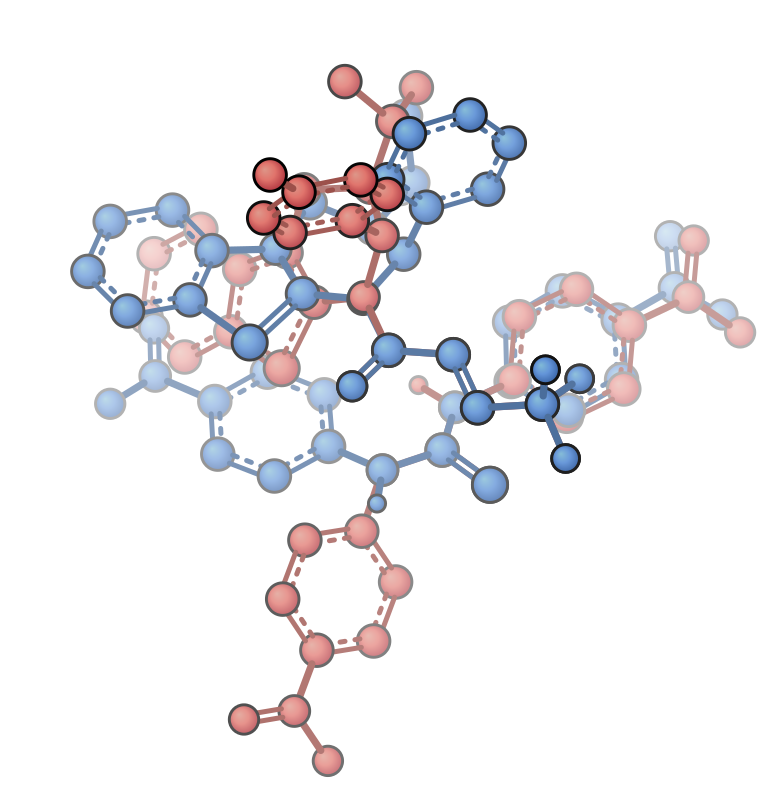

rxembed | resolve: graft C16, O17, C18, C19, C20, F21, F22, F23, N37, C38, S39, N40
rxembed | embed: 12 seeds (74 atoms, 2 fragments, 66 constraints)
rxembed | minimize: dropped 8 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 4 kept
rxembed | prune[rmsd]: 4 -> 4  (merged 0 near-duplicates; see .duplicates())


  nitro-fused (N-acylated): 4 confs | forming C(beta)-S held 2.266 A (DFT 2.266) | net charge 0


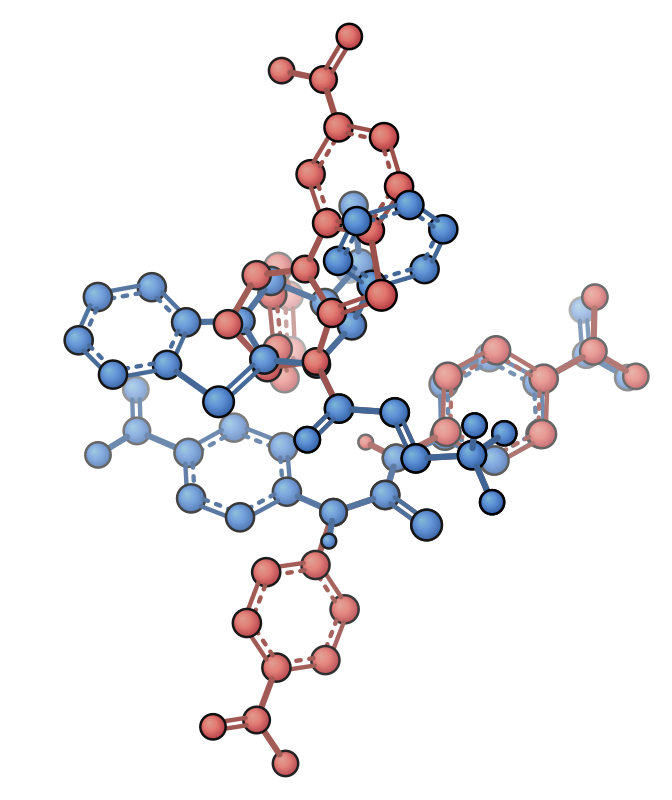

In [ ]:
ref = _xyz_to_mol("structures/thia-ma.xyz", 0)
P = ref.GetConformer().GetPositions()
NUC = "O=[N+]([O-])c1ccc([N-]C(=S)Nc2ccc([N+](=O)[O-])cc2)cc1"  # deprotonated bis(p-nitrophenyl)thiourea (conserved)
ACYL_SM, THIO_SM = (
    "C(=O)C=CC(F)(F)F",
    "NC(=S)N",
)  # conserved acyl (holds the reacting beta-C) + thiourea core (holds S47)
acyl_ts = ref.GetSubstructMatch(Chem.MolFromSmarts(ACYL_SM))  # the TS atoms of each conserved motif (correct order)
thio_ts = ref.GetSubstructMatch(Chem.MolFromSmarts(THIO_SM))

ISOTHIOURONIUMS = {  # the acyl (with its reacting beta-C) is HELD; only the isothiourea backbone changes
    "HyperBTM (original)": "CC(C)[C@@H]1Cn2c([s+]c3ccccc32)N(C(=O)/C=C/C(F)(F)F)[C@@H]1c1ccccc1",
    "BTM (drop the i-Pr)": "C1Cn2c([s+]c3ccccc32)N(C(=O)/C=C/C(F)(F)F)[C@@H]1c1ccccc1",
    "p-tolyl variant": "CC(C)[C@@H]1Cn2c([s+]c3ccccc32)N(C(=O)/C=C/C(F)(F)F)[C@@H]1c1ccc(C)cc1",
    # a nitro-benzothiazolium isothiourea, acylated at its Lewis-base imine N (-> N+, the acyl isothiouronium):
    "nitro-fused (N-acylated)": "[O-][N+]([O-])=C1C=Cc2[s+]c3n(c2=C1)C1CC([N+](C(=O)/C=C/C(F)(F)F)=3)c2ccccc21",
}
for label, itu in ISOTHIOURONIUMS.items():
    asm = Chem.AddHs(Chem.MolFromSmiles(f"{itu}.{NUC}"))
    n0 = Chem.MolFromSmiles(itu).GetNumAtoms()
    acyl_a = asm.GetSubstructMatch(Chem.MolFromSmarts(ACYL_SM))  # same SMARTS -> atoms corresponding to acyl_ts
    thio_a = tuple(n0 + i for i in Chem.MolFromSmiles(NUC).GetSubstructMatch(Chem.MolFromSmarts(THIO_SM)))
    core = {a: tuple(P[t]) for a, t in zip(acyl_a, acyl_ts)}  # graft the whole conserved acyl to its TS geometry...
    core.update({a: tuple(P[t]) for a, t in zip(thio_a, thio_ts)})  # ...and the thiourea core to its TS geometry
    ens = graft(asm, core, n=12).minimize().prune()  # more seeds — the strained charged rings drop some in the gate
    beta, s47 = asm.GetSubstructMatch(Chem.MolFromSmarts("[CH1]=[CH1]C(F)(F)F"))[1], thio_a[thio_ts.index(47)]
    dcs = np.mean([T.GetBondLength(ens.mol.GetConformer(c), beta, s47) for c in ens.ids])
    print(
        f"  {label:22s}: {ens.n} confs | forming C(beta)-S held {dcs:.3f} A (DFT 2.266) | net charge {Chem.GetFormalCharge(asm)}"
    )
    low = ens.lowest(1)  # geometric align on the conserved reactive core (acyl + thiourea), then overlay
    amap = list(zip(acyl_a, acyl_ts)) + list(zip(thio_a, thio_ts))
    rdMolAlign.AlignMol(low.mol, ref, prbCid=low.ids[0], refCid=0, atomMap=amap)
    display(
        xyzrender.render(  # original TS (blue) vs the swapped isothiouronium (red), superposed on the core
            xyzrender.load("structures/thia-ma.xyz"),
            mol_color=ORIG,
            overlay=low.dump(tempfile.mktemp(suffix=".xyz")),
            overlay_color=NEW,
            auto_align=False,
            no_hy=True,
        )
    )

## 5 · The careful bits — reacting fragments, and metals

Two things that need care, so they are not surprises:

1. **Locate reacting atoms by their conserved anchor**, not the whole fragment — a mutated fragment (or one
   whose bonds change at the TS: a mid-reaction boron/carbon with different valence/aromaticity) won't match
   the TS whole. The anchor SMARTS above (`[#5]c` borane vs `[#5]O` boronate) do exactly this and disambiguate
   the two borons.
2. **Metals** — to swap a ligand backbone you need the complex as a graph/SMILES, which ordinary perception
   won't give for a transition metal. `tmc_round` perceives a metal TS into a dative RDKit Mol (keeping the
   3-D conformer) and a valid SMILES — the starting point for writing the swapped-ligand assembly; the graft
   recipe is then identical. (Optional dependency — shown here if importable.)

In [ ]:
try:
    from tmc_round import perceive

    dative = perceive.determine_bonds_tmc(perceive.read_xyz("structures/mn-h2.xyz"), total_charge=0)
    smi = Chem.MolToSmiles(dative)
    print(f"tmc_round perceived mn-h2 (Fe/Mn PNN): SMILES parses back = {Chem.MolFromSmiles(smi) is not None}")
    print("  ->", smi[:90], "...")
    print("  swap the ligand fragment in this SMILES, then graft the Mn-H reacting core exactly as above.")
except ImportError:
    print("tmc_round not installed (optional) — install it to perceive a metal TS into a swappable SMILES.")

tmc_round not installed (optional) — install it to perceive a metal TS into a swappable SMILES.


## 6 · Proof — MC-search a mutant, overlay on the original

The payoff: the both-mutated molecule (new catalyst *and* new substrate) embedded **and MC-searched**, then
overlaid on the original DFT TS. The reacting core coincides; the swapped periphery — piperidine vs. TMP,
phenyl vs. thienyl — is what visibly differs. Two SMILES changes, a new TS candidate, provably built on the
real reacting geometry, ready to hand to a QM optimiser.

rxembed | resolve: graft B0, C1, B17, H28
rxembed | embed: 8 seeds (61 atoms, 2 fragments, 6 constraints)
rxembed | mc: 4 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +18 (openconf 'ensemble', pose-constrained around seeds; total 26)
rxembed | prune[rmsd]: 26 -> 14  (merged 12 near-duplicates; see .duplicates())


both-mutated TS: 14 MC conformers | B(sub)-B(cat) held 2.164 A


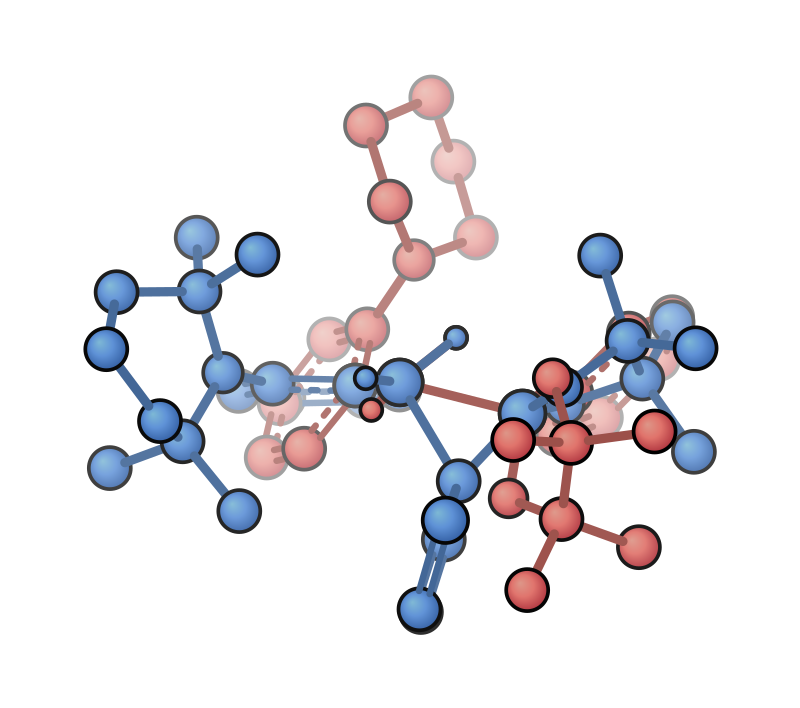

In [ ]:
ref = _xyz_to_mol("structures/jacob_ts4.xyz", 0)
P = ref.GetConformer().GetPositions()
asm = Chem.AddHs(Chem.MolFromSmiles("Bc1ccccc1N1CCCCC1.CC1(C)OB(c2ccccc2)OC1(C)C"))  # the both-mutant, fresh
bB = asm.GetSubstructMatch(Chem.MolFromSmarts(BORANE_B))[0]
oB = asm.GetSubstructMatch(Chem.MolFromSmarts(BORONATE_B))[0]
ipso = asm.GetSubstructMatch(Chem.MolFromSmarts(IPSO_C))[1]
hyd = next(nb.GetIdx() for nb in asm.GetAtomWithIdx(bB).GetNeighbors() if nb.GetAtomicNum() == 1)
core = {bB: tuple(P[11]), oB: tuple(P[32]), hyd: tuple(P[27]), ipso: tuple(P[1])}

searched = graft(asm, core, n=8).mc(preset="ensemble").minimize().prune()  # 'ensemble' is the constrained-run preset
print(
    f"both-mutated TS: {searched.n} MC conformers | B(sub)-B(cat) held "
    f"{np.mean([T.GetBondLength(searched.mol.GetConformer(c), bB, oB) for c in searched.ids]):.3f} A"
)
low = searched.lowest(1)  # geometric align on the reactive core, then overlay
rdMolAlign.AlignMol(low.mol, ref, prbCid=low.ids[0], refCid=0, atomMap=[(bB, 11), (oB, 32), (hyd, 27), (ipso, 1)])
xyzrender.render(  # original TS (blue) + MC-searched mutant (red), superposed on the reacting core
    xyzrender.load("structures/jacob_ts4.xyz"),
    mol_color=ORIG,
    overlay=low.dump(tempfile.mktemp(suffix=".xyz")),
    overlay_color=NEW,
    auto_align=False,
    no_hy=True,
)